In [23]:
import yfinance as yf
import pandas as pd
from datetime import datetime, timedelta

end = datetime.today()
start = end - timedelta(days=30)

xom = yf.download("XOM", start=start, end=end)[["Open"]].rename(columns={"Open": "XOM"})
googl = yf.download("GOOGL", start=start, end=end)[["Open"]].rename(columns={"Open": "GOOGL"})
df = xom.join(googl, how="outer")
print("Last updated:", datetime.now())
df

[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed

Last updated: 2026-03-09 08:23:01.677678


Price,XOM,GOOGL
Ticker,XOM,GOOGL
Date,,
2026-02-09,148.271701,320.929993
2026-02-10,150.347887,320.970001
2026-02-11,152.950530,318.970001
2026-02-12,153.889999,312.089996
2026-02-13,150.550003,307.730011
2026-02-17,148.199997,300.040009
2026-02-18,148.149994,302.089996
2026-02-19,152.199997,301.820007


In [25]:
msft = yf.download("MSFT", start=start, end=end)[["Open"]].rename(columns={"Open": "MSFT"})
print("MSFT last updated:", datetime.now())
msft

[*********************100%***********************]  1 of 1 completed

MSFT last updated: 2026-03-09 08:24:09.528998


Price,MSFT
Ticker,MSFT
Date,
2026-02-09,403.928068
2026-02-10,418.664403
2026-02-11,415.232230
2026-02-12,404.077704
2026-02-13,403.528974
2026-02-17,398.310879
2026-02-18,397.223349
2026-02-19,400.690002


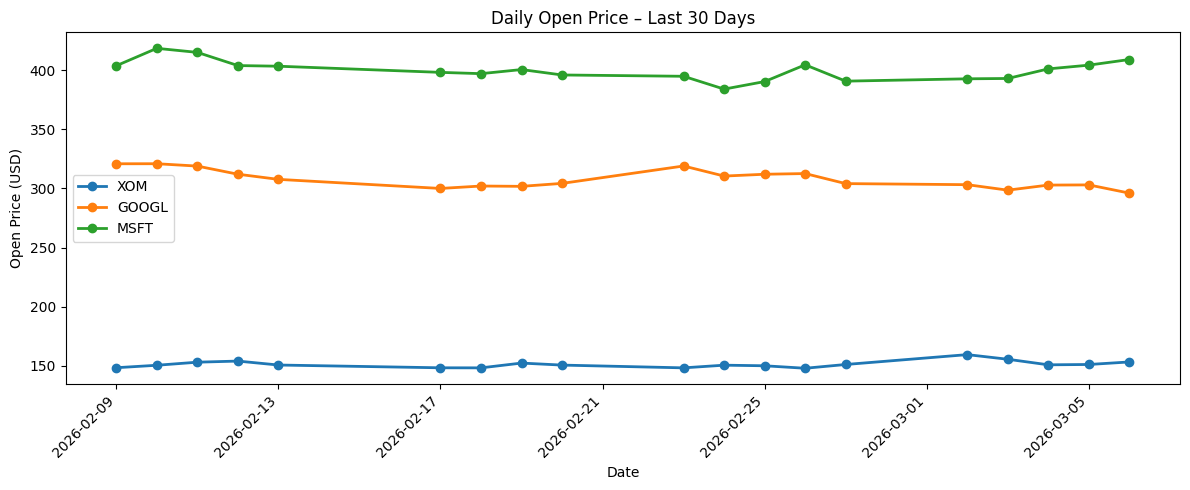

In [26]:
import matplotlib.pyplot as plt

all_stocks = df.join(msft, how="outer")

fig, ax = plt.subplots(figsize=(12, 5))
for col, color in zip(["XOM", "GOOGL", "MSFT"], ["#1f77b4", "#ff7f0e", "#2ca02c"]):
    ax.plot(all_stocks.index, all_stocks[col], marker="o", linewidth=2, color=color, label=col)

ax.set_title("Daily Open Price – Last 30 Days")
ax.set_xlabel("Date")
ax.set_ylabel("Open Price (USD)")
ax.legend()
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()